In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


458


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}


---
## Average all the spectrum.

100%|██████████| 43042/43042 [00:03<00:00, 11637.73it/s]


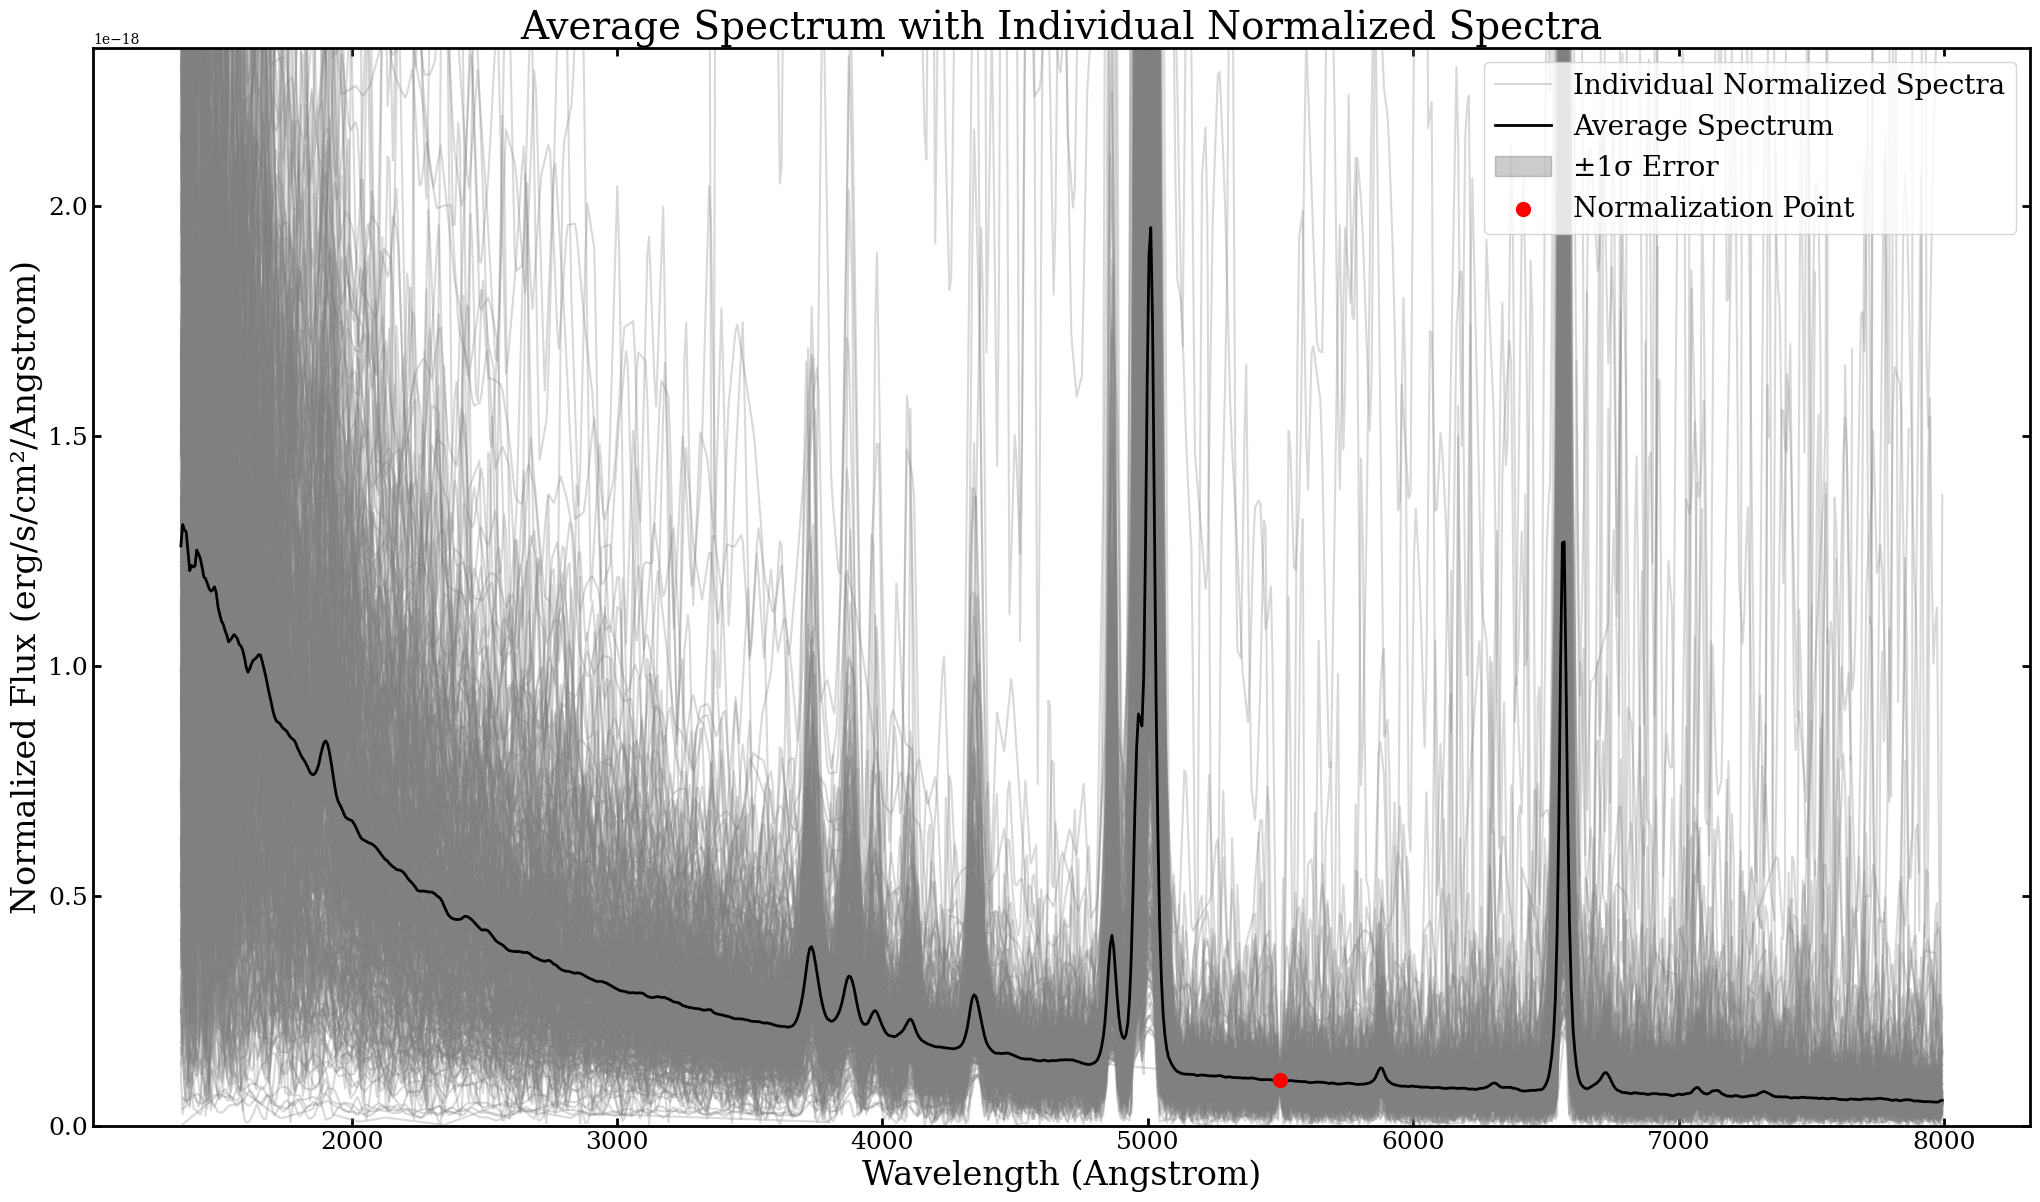

In [2]:
averager=FL.SpectrumAverager()
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator(), total=len(DJAv4Catalog.catalog)):
    if not catalog['sample_flag']:
        continue

    averager.load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

averager.create_common_wavelength_grid(wavelength_range=(1350,8000))
averager.interpolate_spectra(interpolation_method='linear')
averager.spectrum_normalization(reference_wavelength=5500.0, target_flux=1e-19)
averager.spectrum_normalization()
averager.compute_average_spectrum(method='mean', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)

---
## Binning the spectrum and average different attenuation spectrum.

In [95]:
group_conditions = [(-0.1,0.05),(0.06,0.12), (0.12,0.24),(0.24,0.36),(0.36,0.48),(0.48,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

In [96]:
group0_averager=FL.SpectrumAverager()
group1_averager=FL.SpectrumAverager()
group2_averager=FL.SpectrumAverager()
group3_averager=FL.SpectrumAverager()
group4_averager=FL.SpectrumAverager()
group5_averager=FL.SpectrumAverager()
group6_averager=FL.SpectrumAverager()


for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
    halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
    hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
    balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
    group_index=group_condition_func(balmer_decrement)
    if group_index==-1:
        continue

    averager_to_use='group'+str(group_index)+'_averager'
    globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)




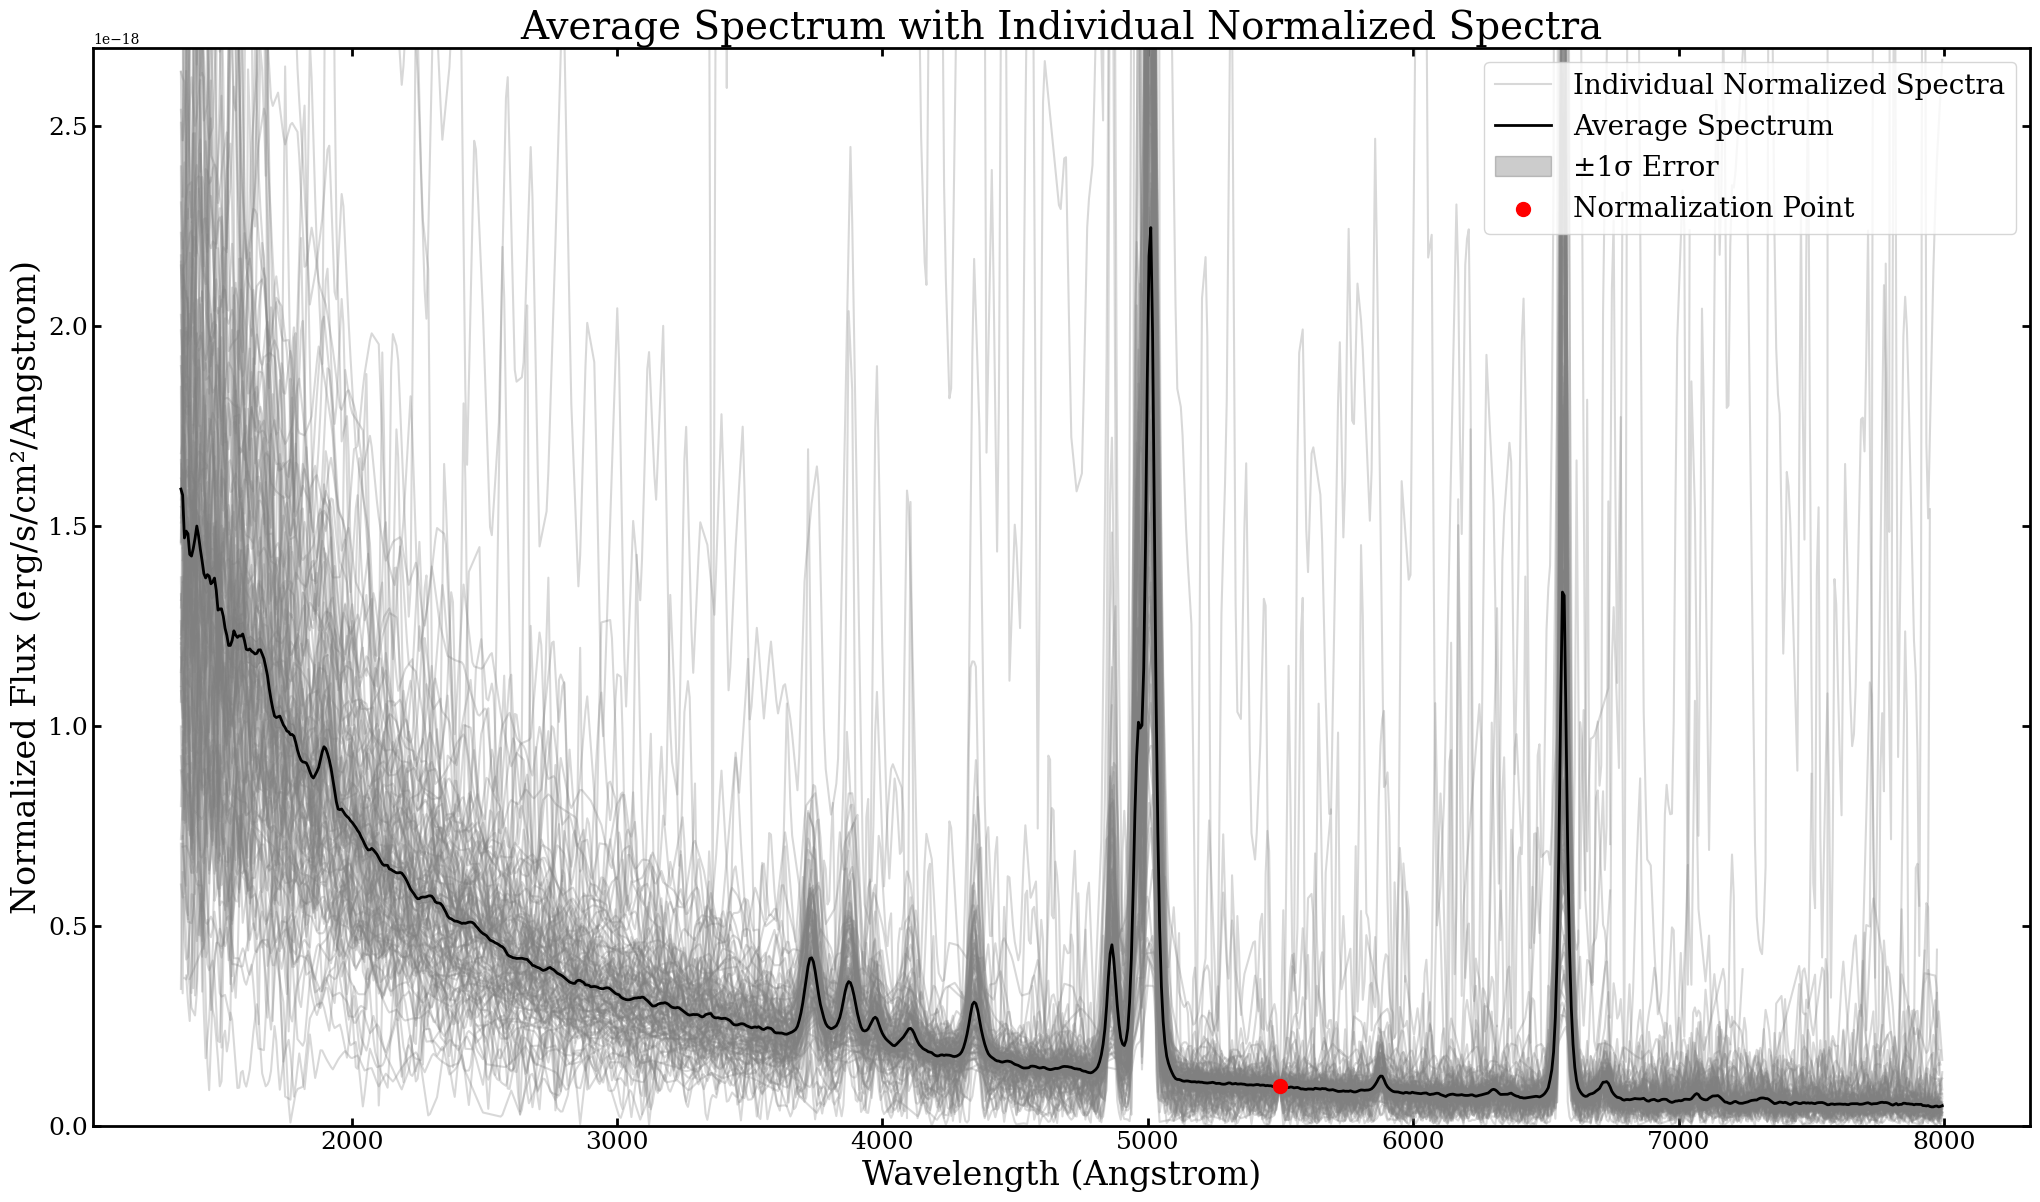

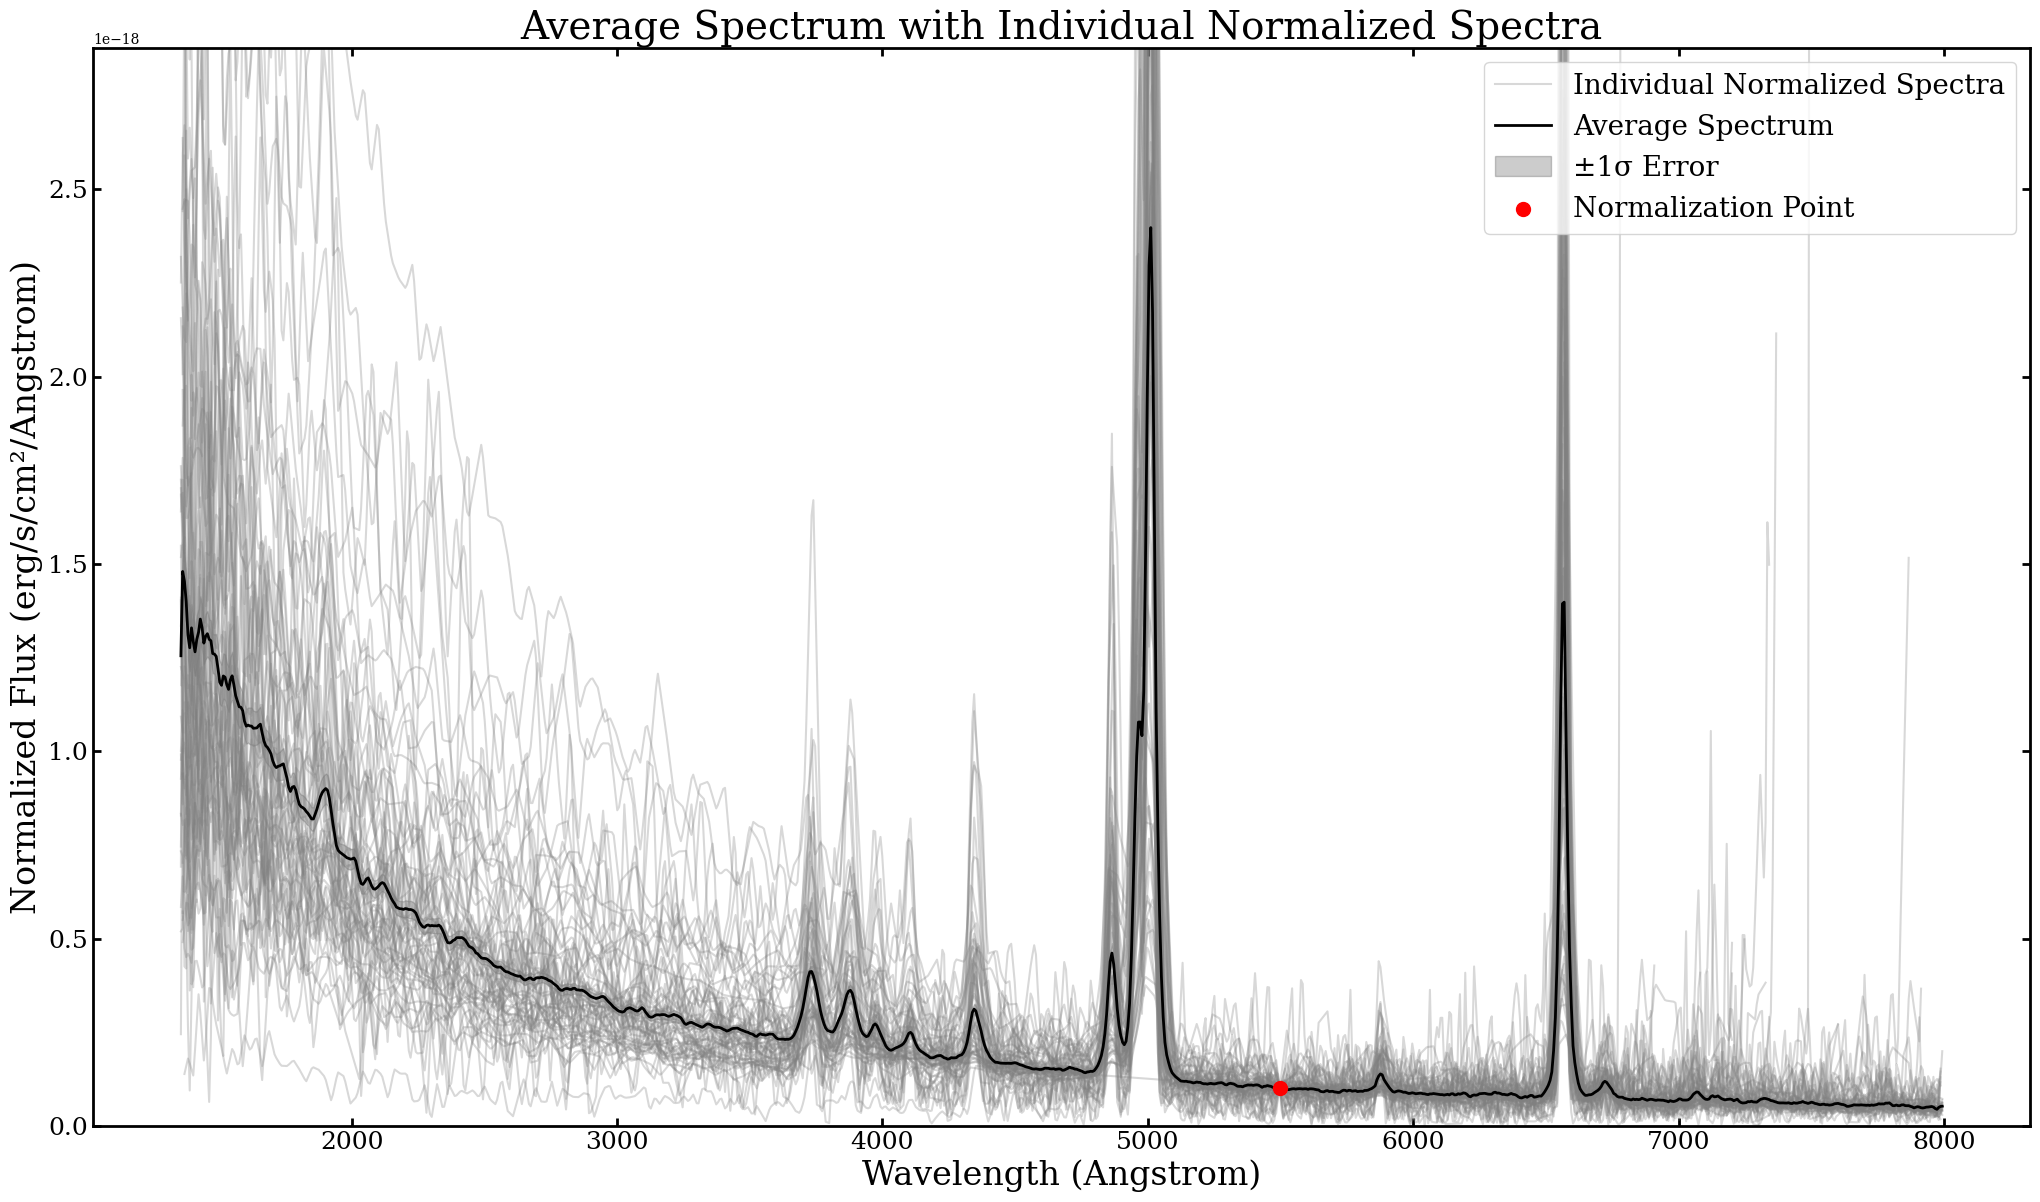

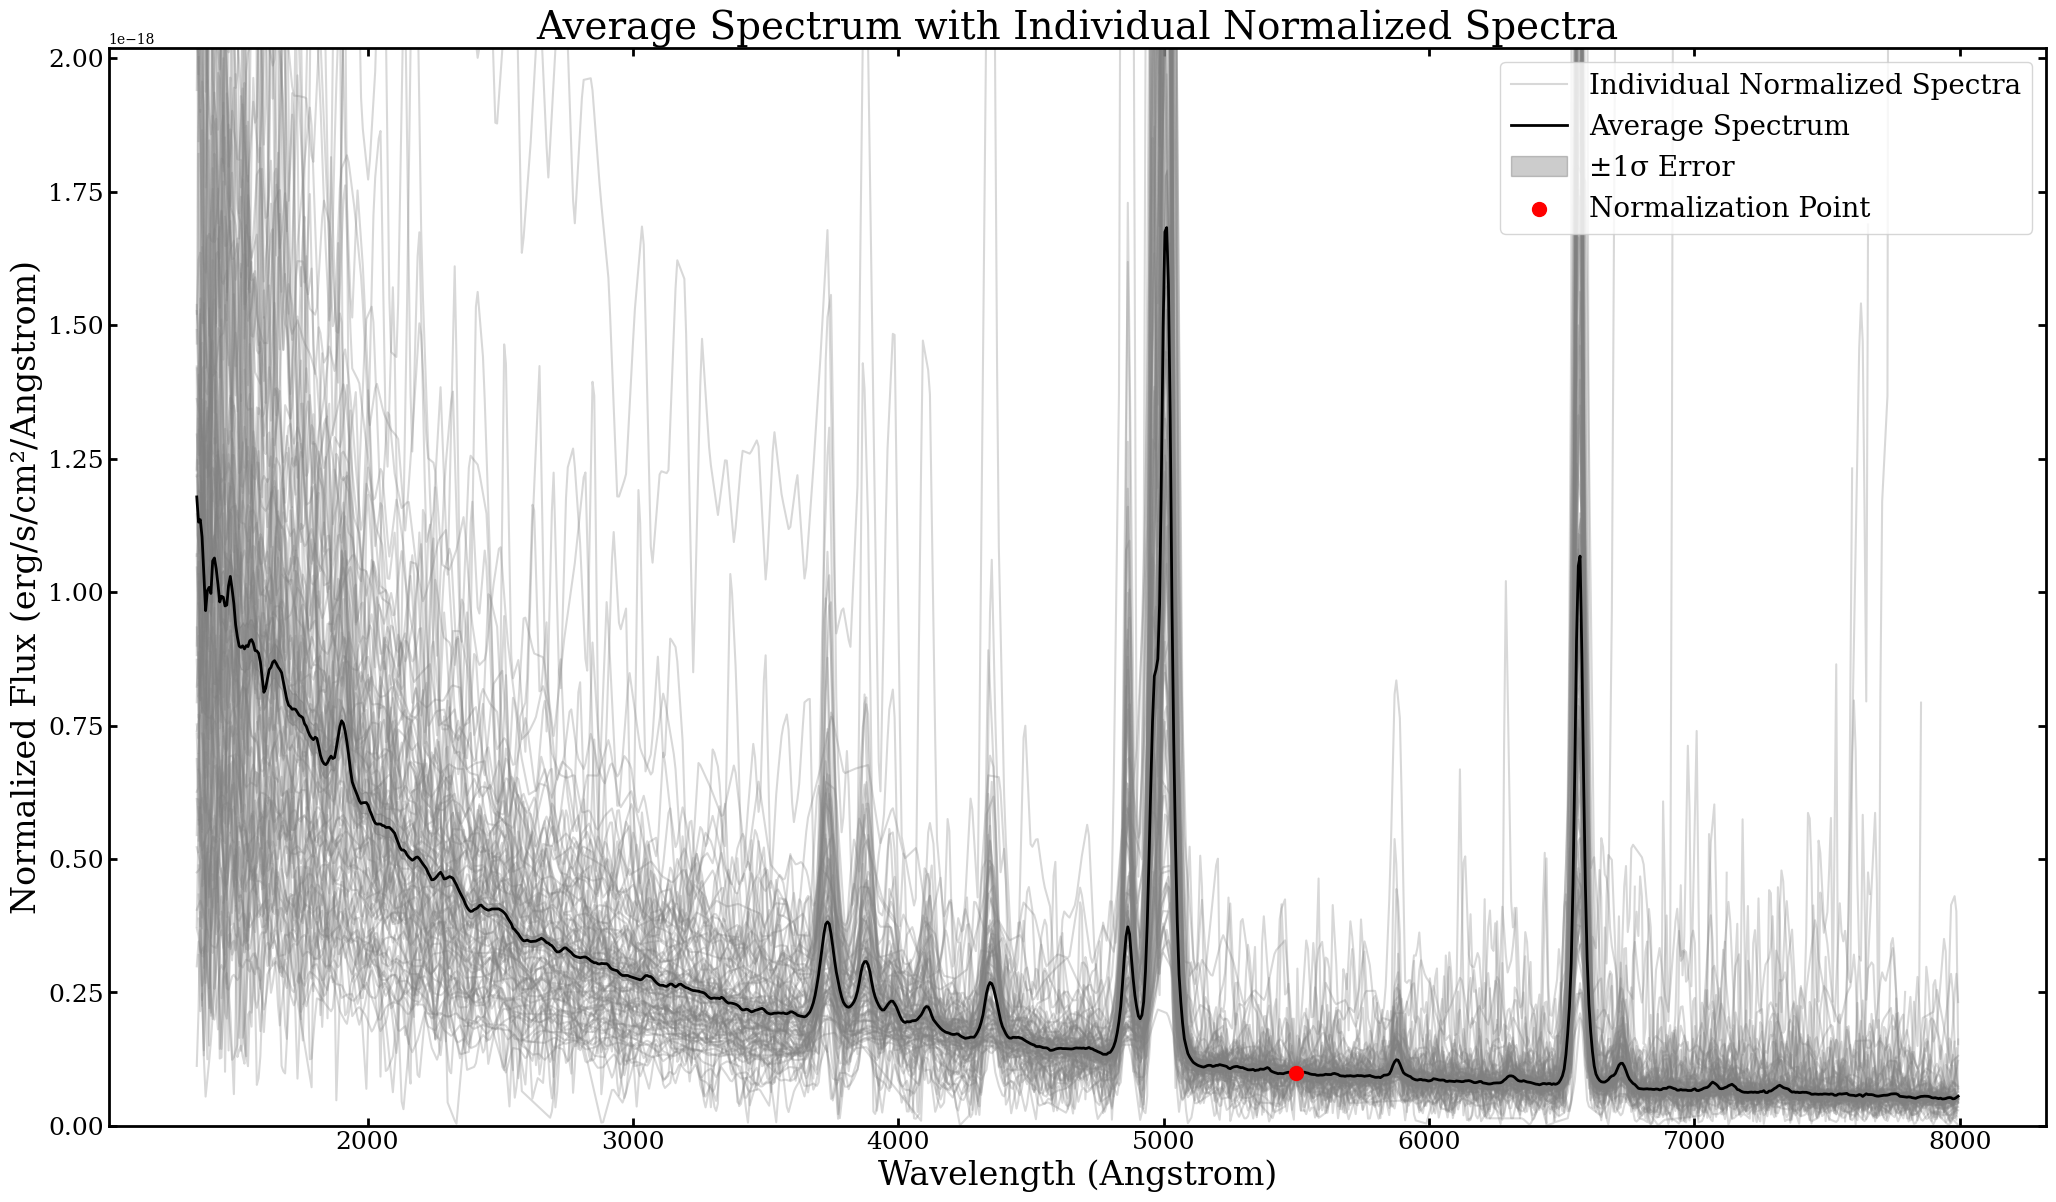

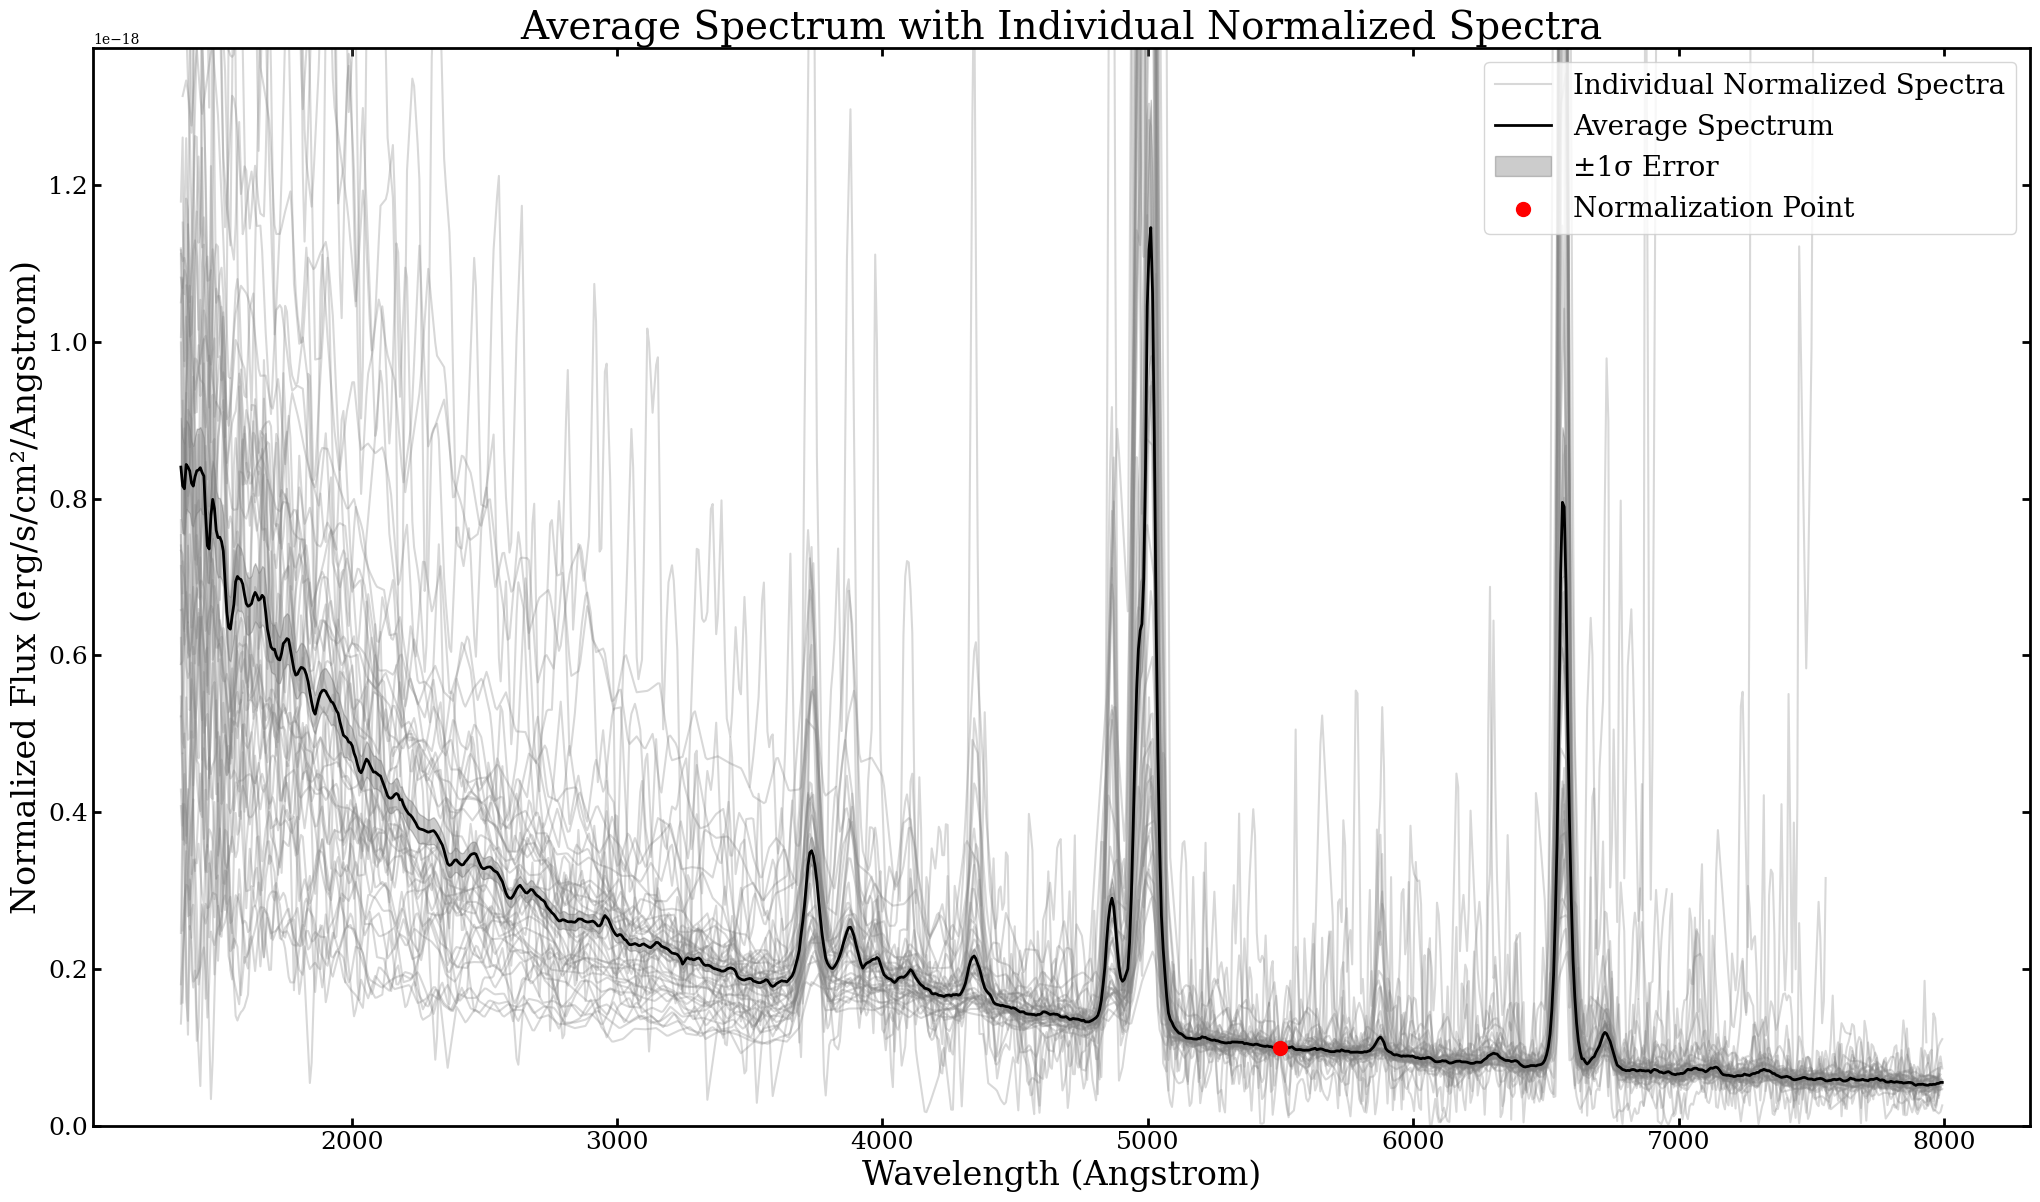

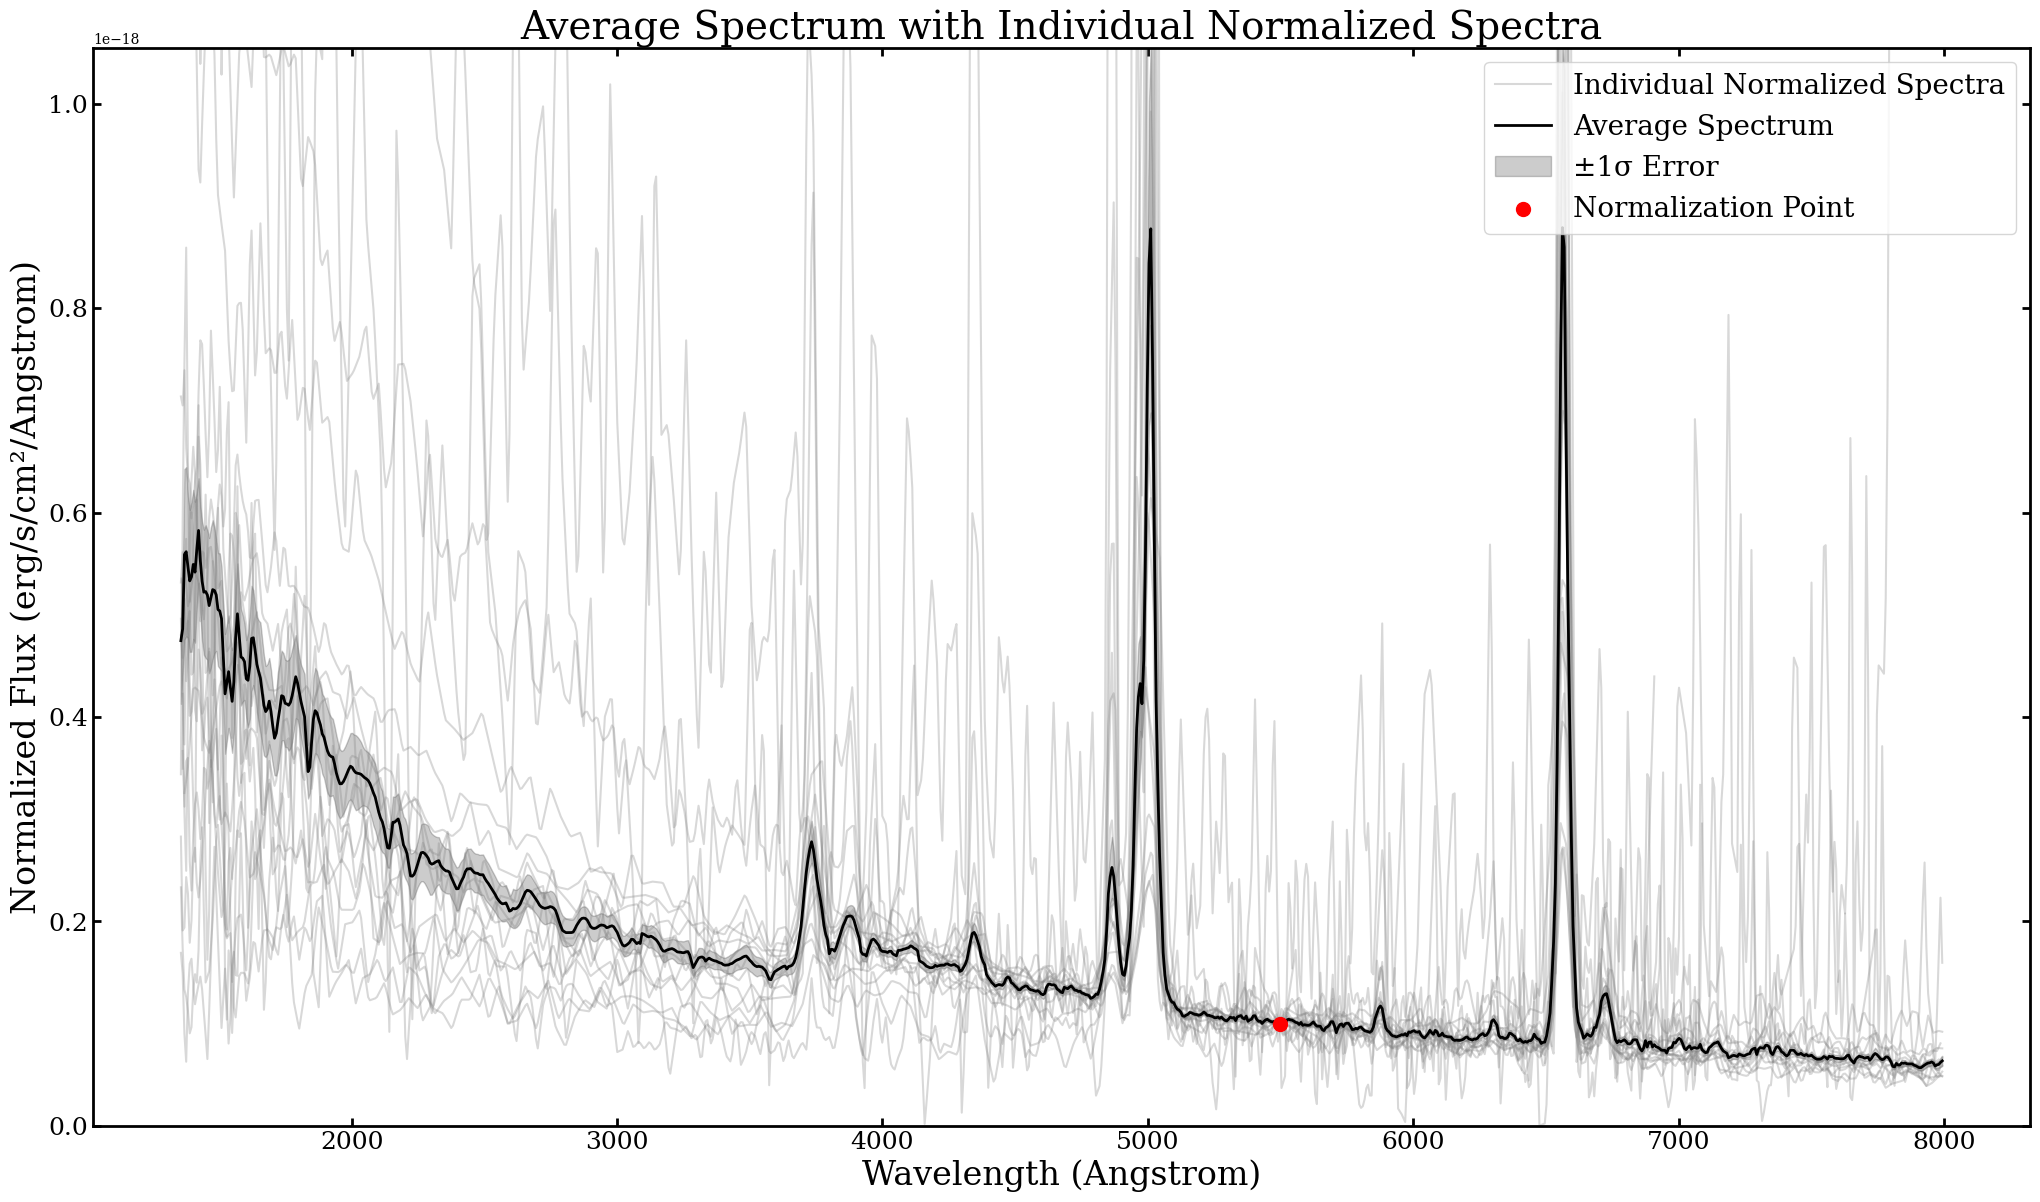

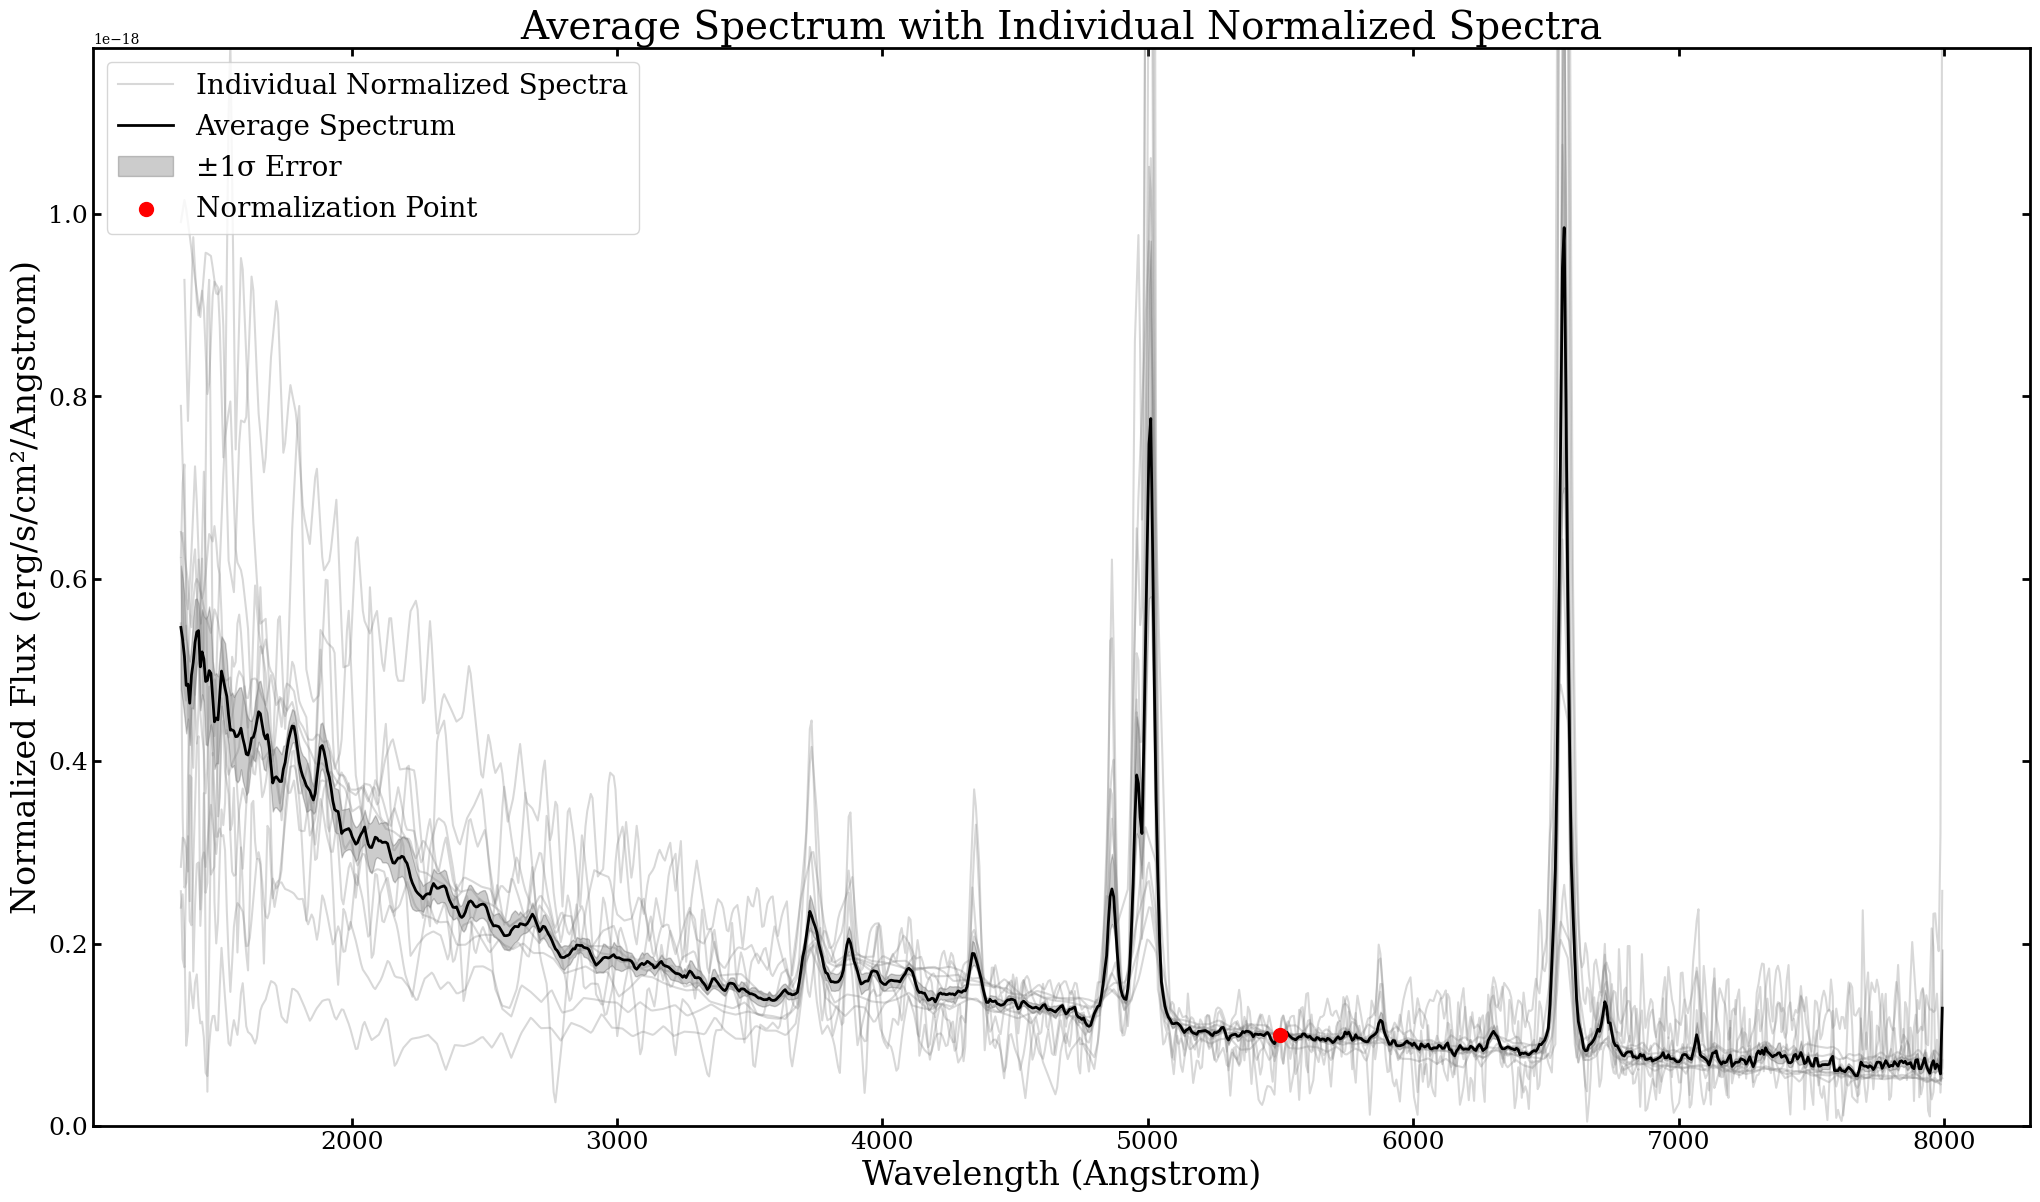

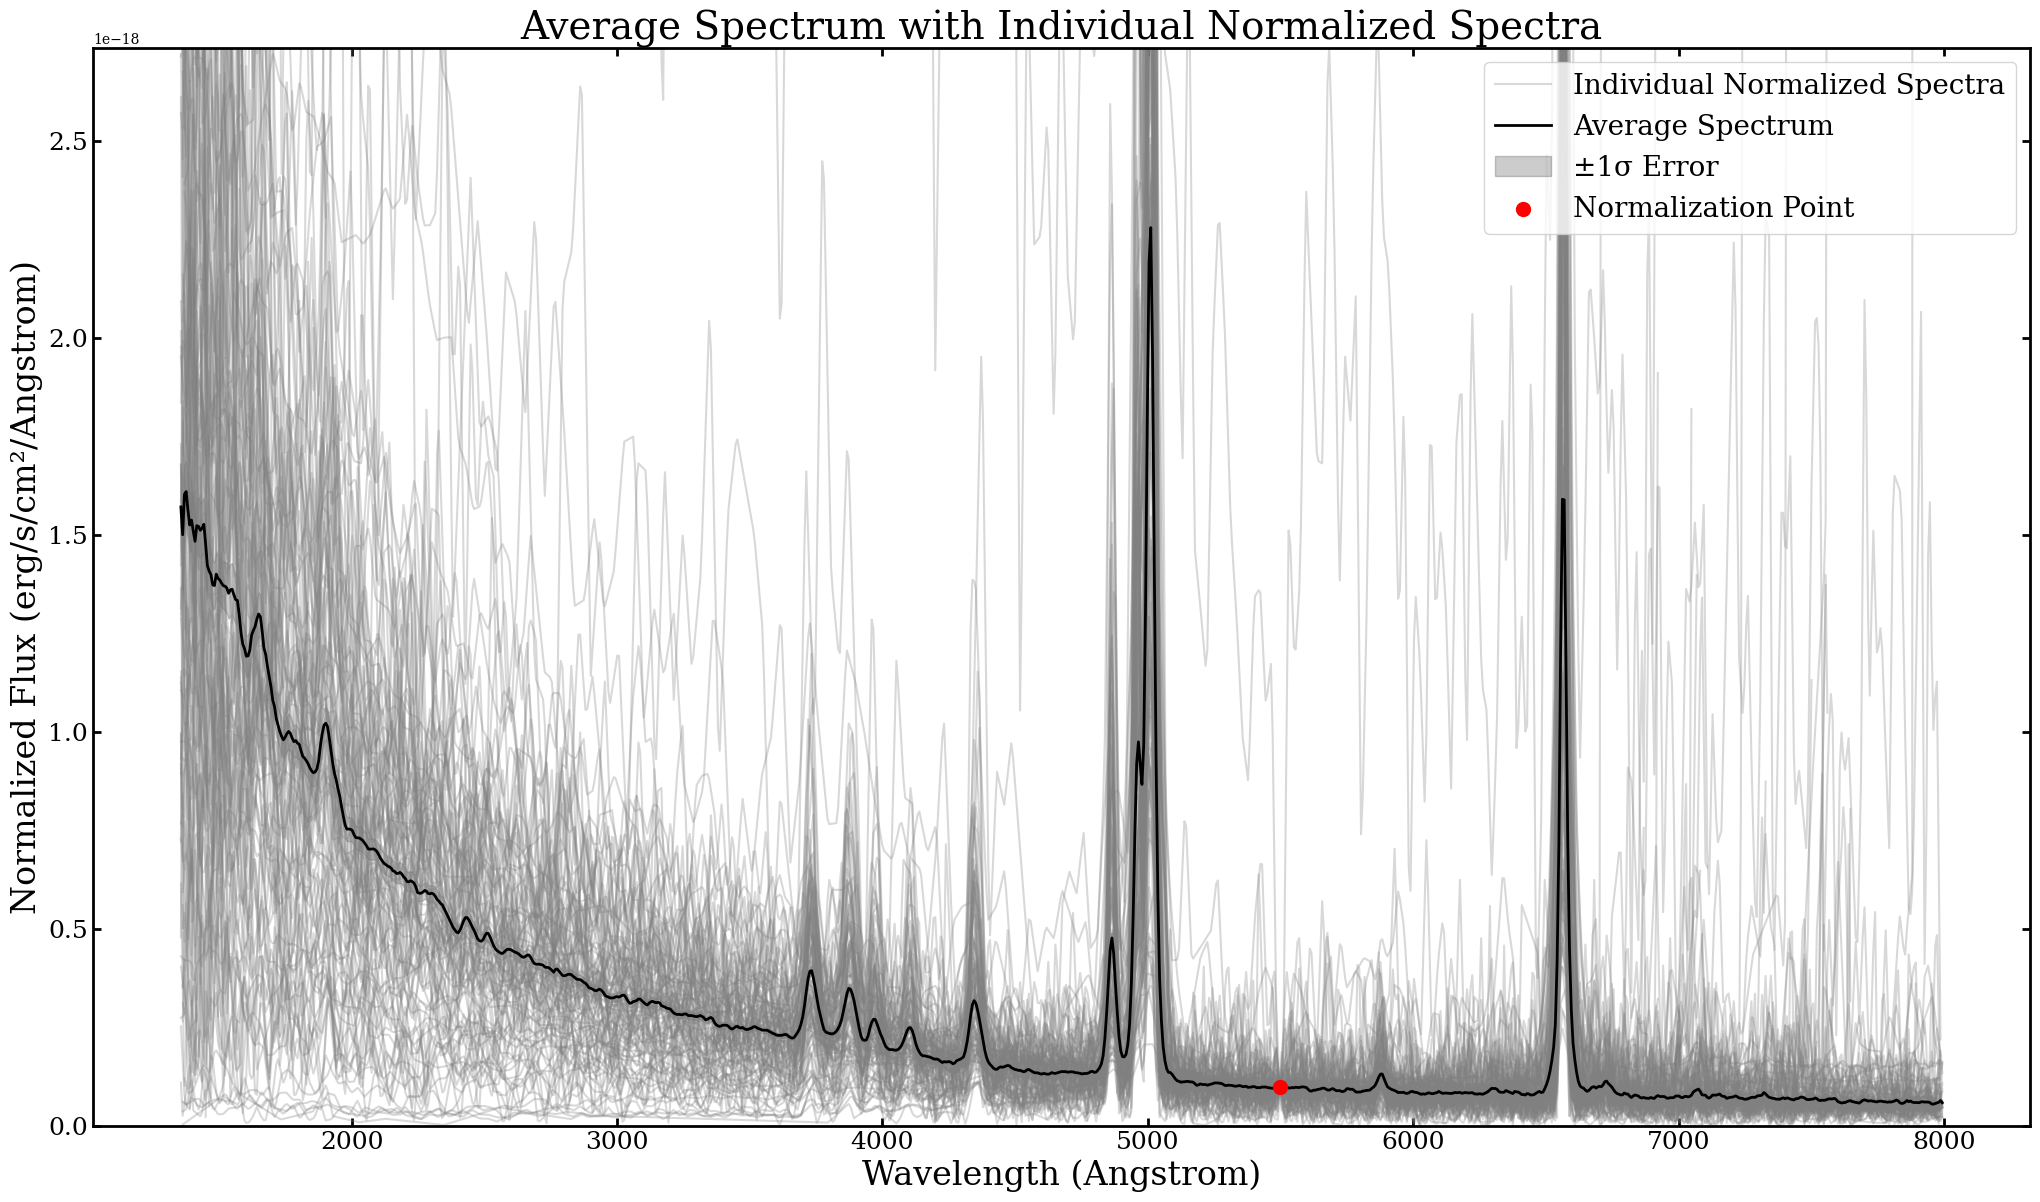

In [98]:
for i in range(7):
    averager_to_use='group'+str(i)+'_averager'
    globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000))
    globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
    globals()[averager_to_use].spectrum_normalization(reference_wavelength=5500.0, target_flux=1e-19)
    globals()[averager_to_use].spectrum_normalization()
    globals()[averager_to_use].compute_average_spectrum(method='mean', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
    globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)

In [ ]:
def power_law(x, amplitude, exponent):
    """
    Power law function for fitting.
    """
    return amplitude * (x ** exponent)

def fit_power_law(restframe_wave, restframe_flux_lambda, initial_guess=(1e-19, -1.0)):
    """
    Fit a power law to the given wavelengths and fluxes.
    """

    fit_mask = (restframe_wave.data >= 1407) & (restframe_wave.data <= 2580)
    wave_to_fit = restframe_wave[fit_mask].data
    flux_to_fit = restframe_flux_lambda[fit_mask].data

    # if np.any(error_to_fit <= 0):
    #     print("Warning: Non-positive error values found. These will be ignored in the fit.")
    #     valid_error_mask = error_to_fit > 0
    #     wave_to_fit = wave_to_fit[valid_error_mask]
    #     flux_to_fit = flux_to_fit[valid_error_mask]
    #     error_to_fit = error_to_fit[valid_error_mask]

    if np.any(np.isnan(flux_to_fit)) :
        print("Warning: NaN values found in flux or error arrays. These will be ignored in the fit.")
        valid_nan_mask = ~np.isnan(flux_to_fit)
        wave_to_fit = wave_to_fit[valid_nan_mask]
        flux_to_fit = flux_to_fit[valid_nan_mask]

    fit_successful = False
    if len(wave_to_fit) > 2:
        try:
            initial_guess = [np.median(flux_to_fit), -1.5]
            popt, pcov = scipy.optimize.curve_fit(
                power_law,
                xdata=wave_to_fit,
                ydata=flux_to_fit,
                p0=initial_guess,
                absolute_sigma=True,
                maxfev=500000
            )

            fit_amplitude, fit_exponent = popt
            perr = np.sqrt(np.diag(pcov))
            fit_amplitude_err, fit_exponent_err = perr
            fit_successful = True

            # print("\n--- Power-law Fit Results ---")
            # print(f"  Amplitude: {fit_amplitude:.3e} ± {fit_amplitude_err:.3e}")
            # print(f"  Exponent:  {fit_exponent:.3f} ± {fit_exponent_err:.3f}")
            # print("---------------------------\n")
            return fit_amplitude, fit_amplitude_err, fit_exponent, fit_exponent_err

        except RuntimeError as e:
            print(f"Fit failed for {surveyid_subid}: {e}")
            return None


In [62]:
decrement_list=[]
uv_list=[]
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    spectrum0=FL.Spectrum_1d(averager.common_wavelength*u.AA, 0, None, averager.average_flux*1e19*u.erg/u.s/u.cm**2/u.AA)
    alpharestFrameWavelength=6563.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    alpha=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    alpharestFrameWavelength=4863.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    beta=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    uv_region_wavelengths = (1407.0, 2580.0) * astropy.units.AA
    spectrum0.set_boundarys(uv_region_wavelengths[0], uv_region_wavelengths[1])
    powerlaw_params=fit_power_law(spectrum0.processing_wavelengths, spectrum0.processing_flux_lambda)
    print(powerlaw_params)

    balmer=(alpha/beta)
    decrement=np.log(balmer/2.86)
    uv=(powerlaw_params[2])
    decrement_list.append(decrement)
    uv_list.append(uv)

(np.float64(24234144.687589966), np.float64(9522263.694157852), np.float64(-1.9705361691717023), np.float64(0.05261478478227961))
(np.float64(15440688.269184327), np.float64(6483909.328576578), np.float64(-1.9196874298538438), np.float64(0.056209605867096564))
(np.float64(2565161.5065913657), np.float64(1301875.6576925102), np.float64(-1.7072351567176995), np.float64(0.06782983615140051))
(np.float64(876032.6736647992), np.float64(555874.8088697268), np.float64(-1.5946073983646778), np.float64(0.08473348584884217))
(np.float64(229286.41226141935), np.float64(211717.56425244376), np.float64(-1.4668411769591256), np.float64(0.12318413212496288))
(np.float64(112844.42132186517), np.float64(106202.57112430954), np.float64(-1.3755134255848382), np.float64(0.1254656031422141))


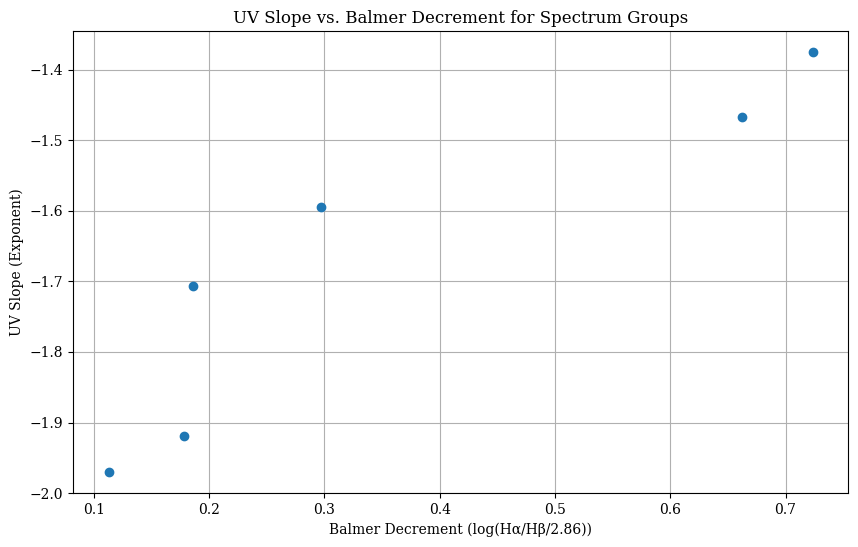

In [63]:
plt.figure(figsize=(10,6))
plt.plot(decrement_list, uv_list, marker='o', linestyle='None')
plt.xlabel('Balmer Decrement (log(Hα/Hβ/2.86))')
plt.ylabel('UV Slope (Exponent)')
plt.title('UV Slope vs. Balmer Decrement for Spectrum Groups')
plt.grid(True)
plt.show()

---
## attenuation curve

In [71]:
group_conditions = [(-0.1,0.05),(0.06,0.12), (0.12,0.24),(0.24,0.36),(0.36,0.48),(0.48,0.6)]
group_decrement_list=[]

for i in range(6):
    decrement_list=[]

    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index!=i:
            continue
        if group_index==-1:
            continue

        decrement_list.append(balmer_decrement)

    group_decrement_list.append(np.mean(decrement_list))



In [72]:
group_decrement_list

[np.float64(-0.022122585990916762),
 np.float64(0.09067005138132825),
 np.float64(0.17487989764906428),
 np.float64(0.28210079960465284),
 np.float64(0.42419142907583174),
 np.float64(0.5291665629705492)]

In [75]:
model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
tau_lambda_list=[]
Q_lambda_list=[]

for i in range(1,6):
    averager_to_use='group'+str(i)+'_averager'
    tau_lambda_list=[]
    groupi_averager=globals()[averager_to_use]
    tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
    tau_lambda_list.append(tau_lambda)
    Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
    Q_lambda_list.append(Q_lambda)

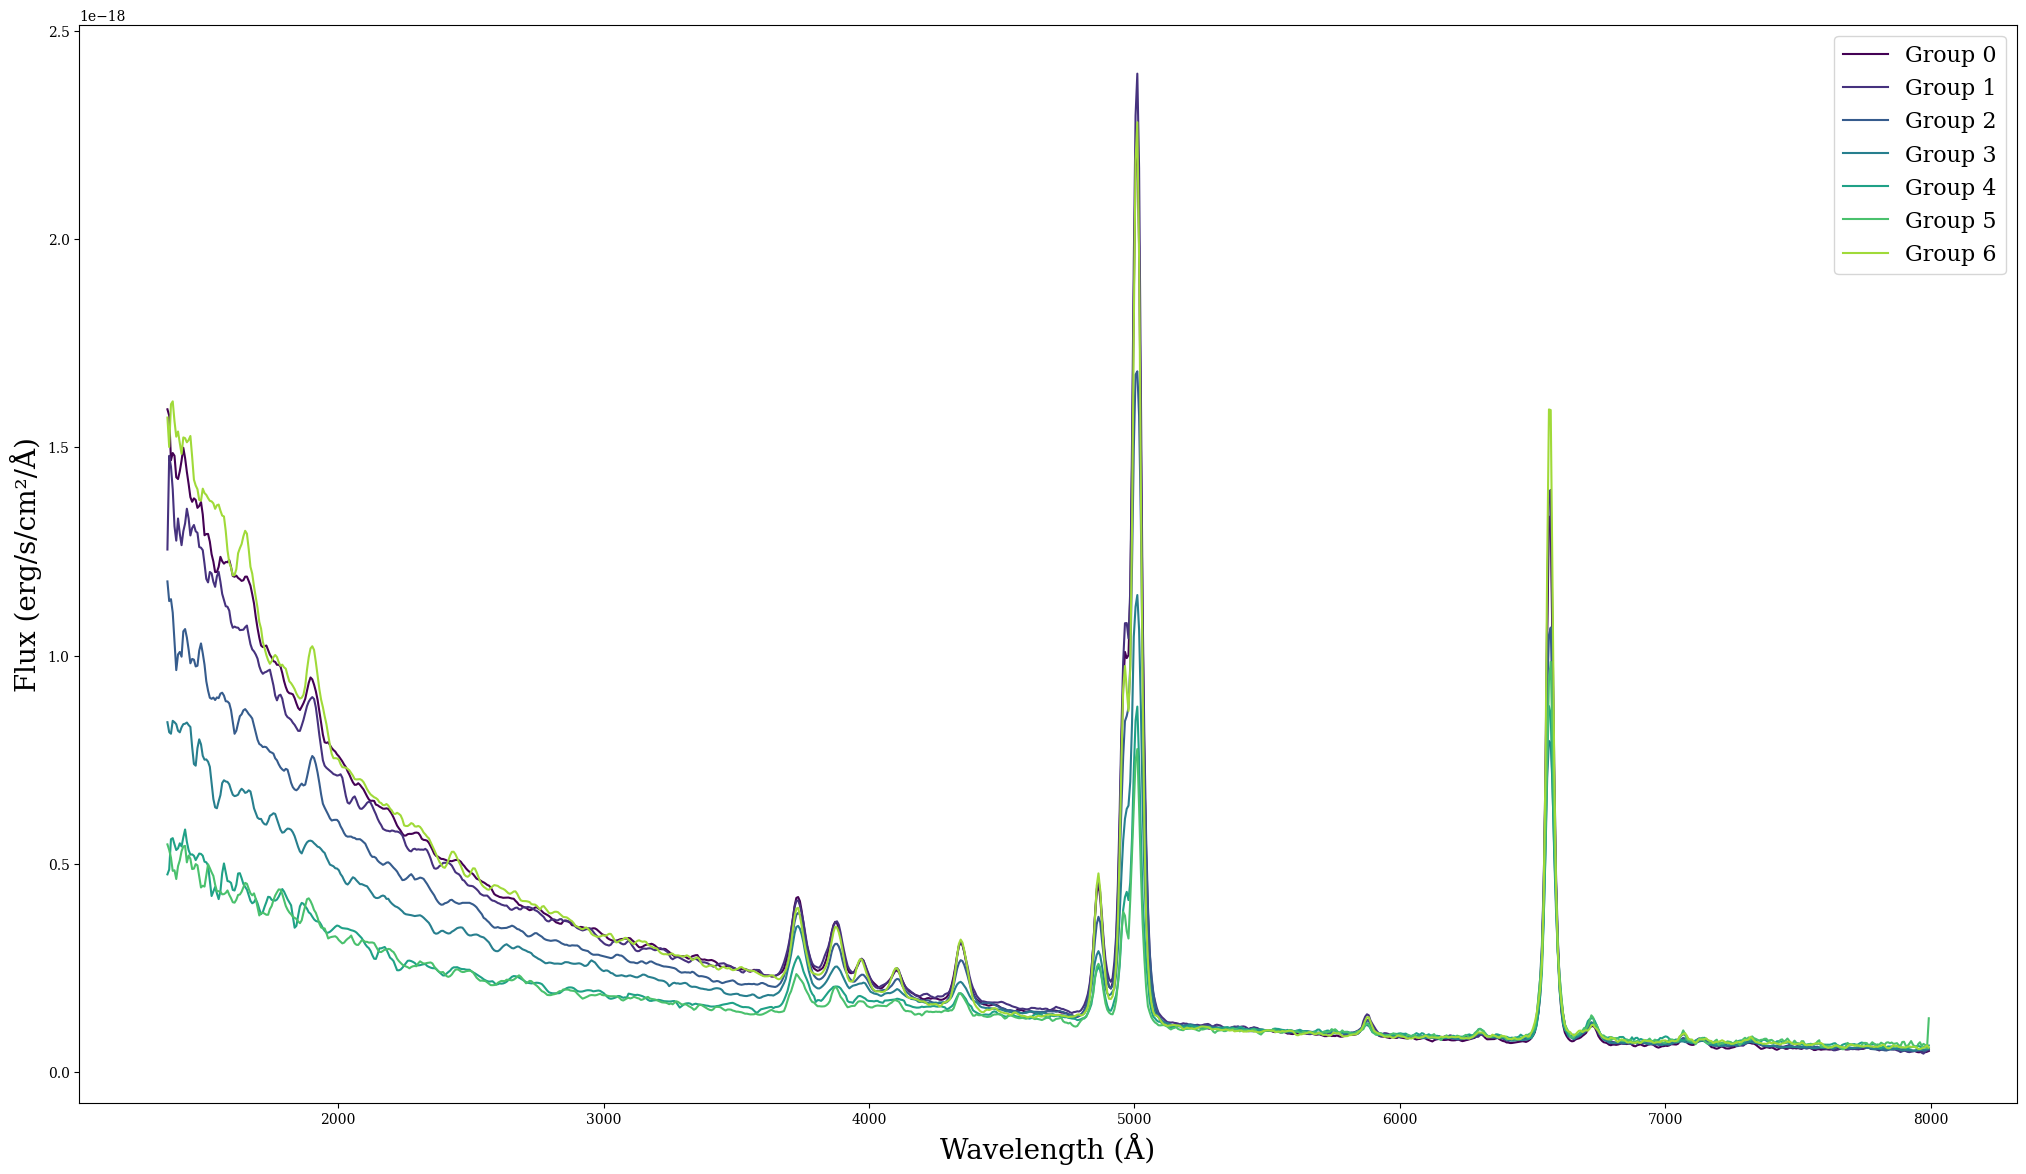

In [100]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,7))
for i in range(7):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
ax.set_xlabel('Wavelength (Å)', fontsize=20)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=20)
ax.legend(fontsize=16)
plt.show()

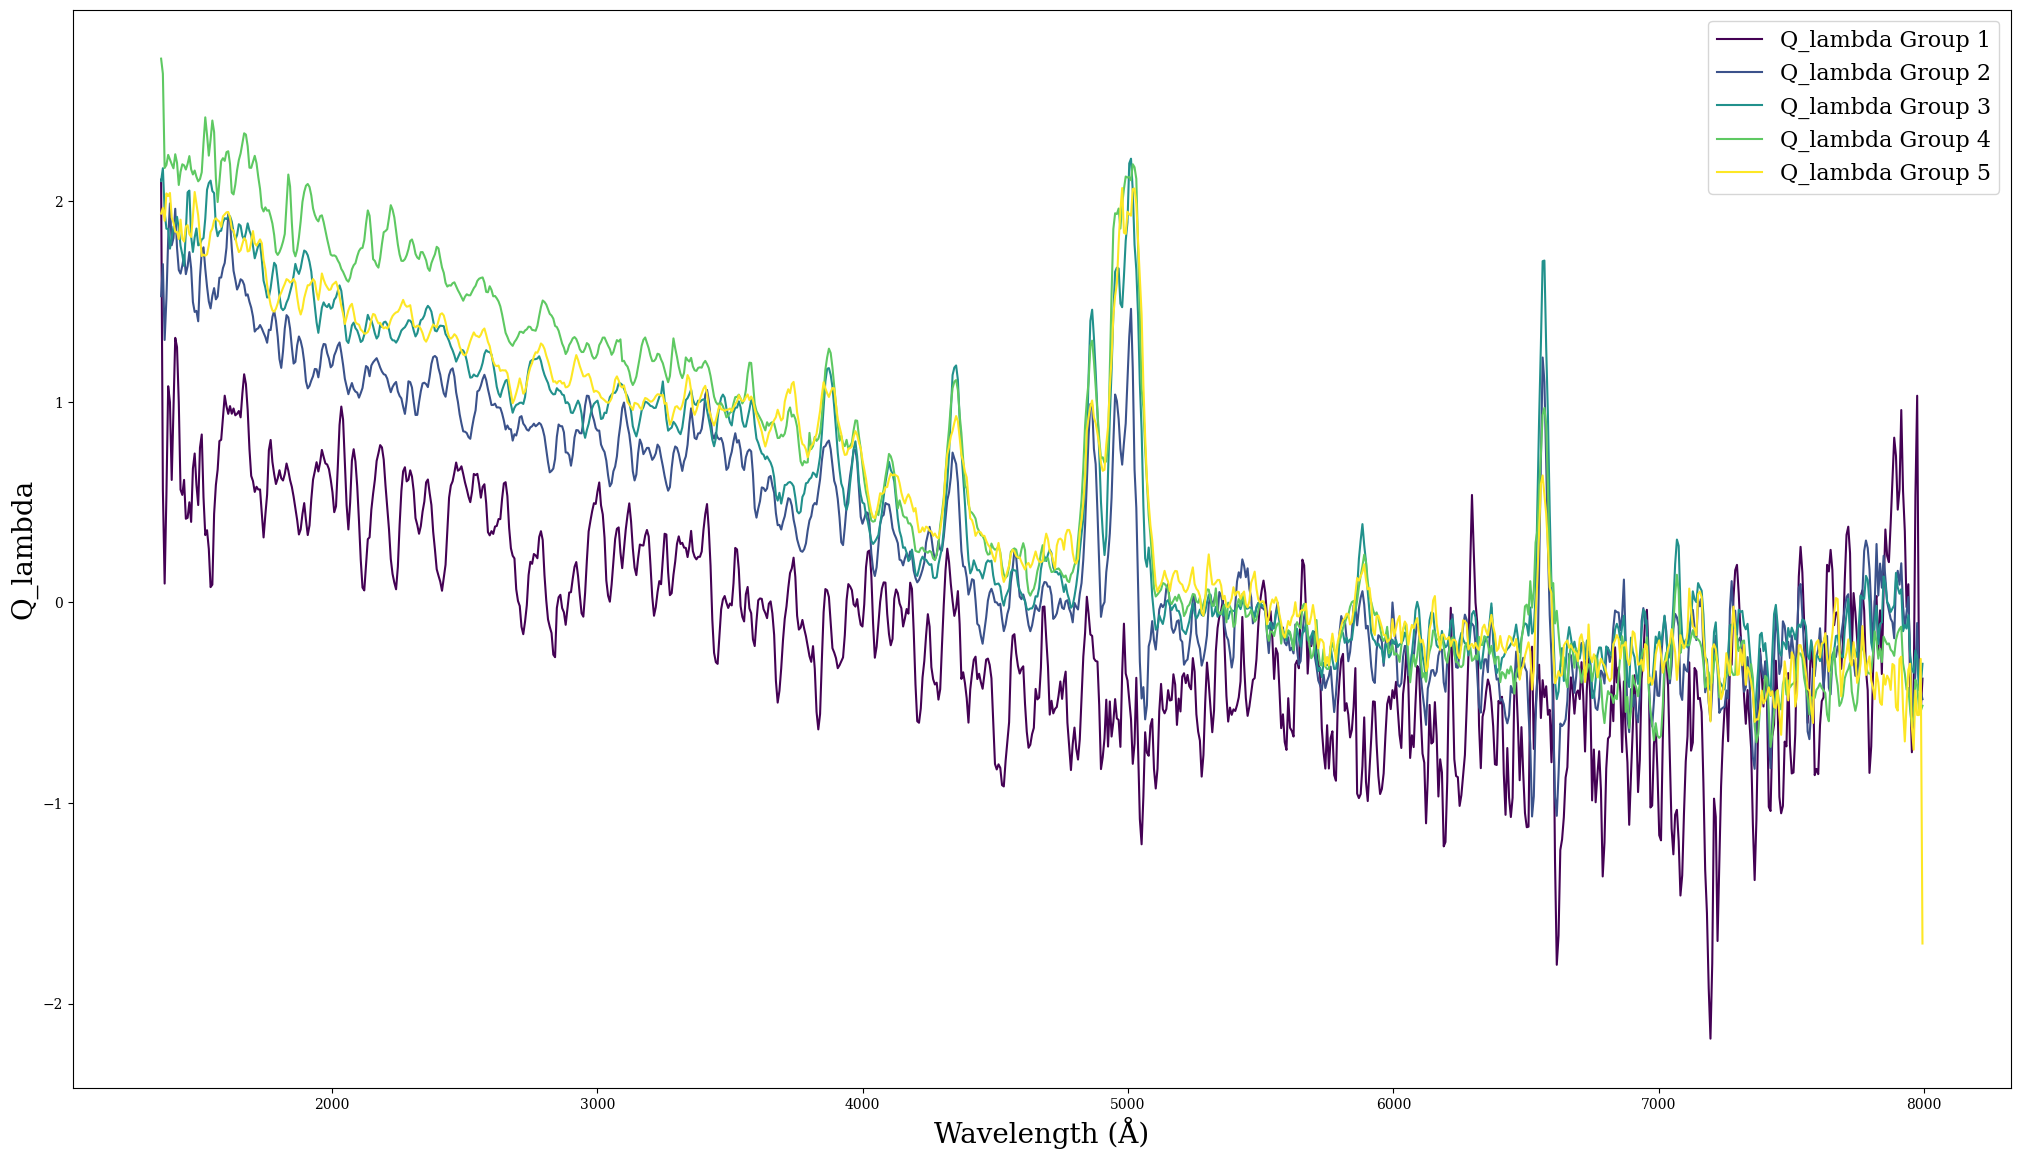

In [81]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,1,5))
for i in range(5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color=colors[i], label='Q_lambda Group '+str(i+1))
ax.set_xlabel('Wavelength (Å)', fontsize=20)
ax.set_ylabel('Q_lambda', fontsize=20)
ax.legend(fontsize=16)
plt.show()

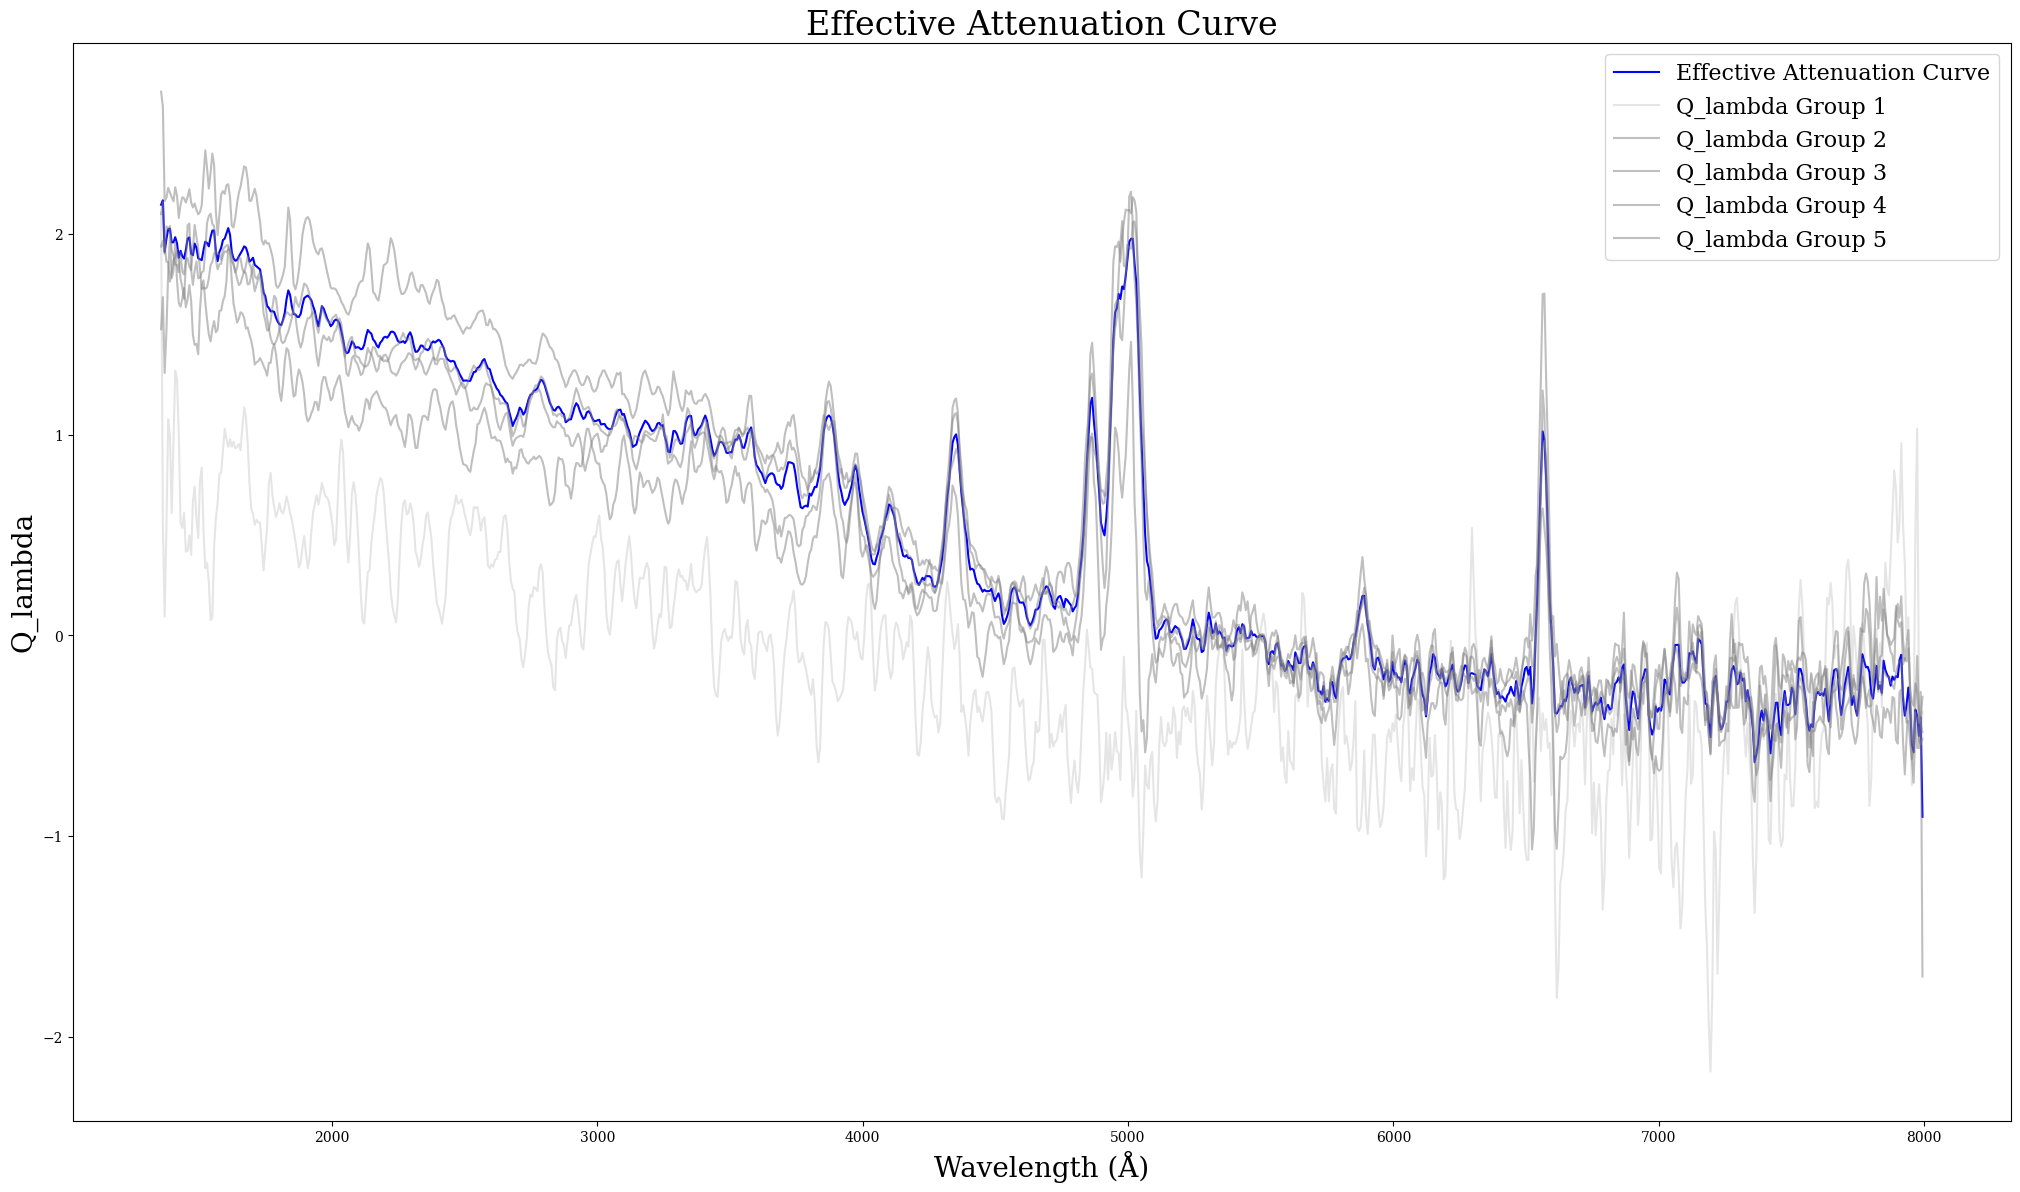

In [90]:
Q_lambda_array=np.array(Q_lambda_list)

effective_attenuation_curve=np.average(Q_lambda_array[1:], axis=0, weights=[group_decrement_list[2]-group_decrement_list[0], group_decrement_list[3]-group_decrement_list[0], group_decrement_list[4]-group_decrement_list[0], group_decrement_list[5]-group_decrement_list[0]])
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
for i in range(0,5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curve', fontsize=24)
plt.legend(fontsize=16)
plt.show()

---
Compare with Calzetti

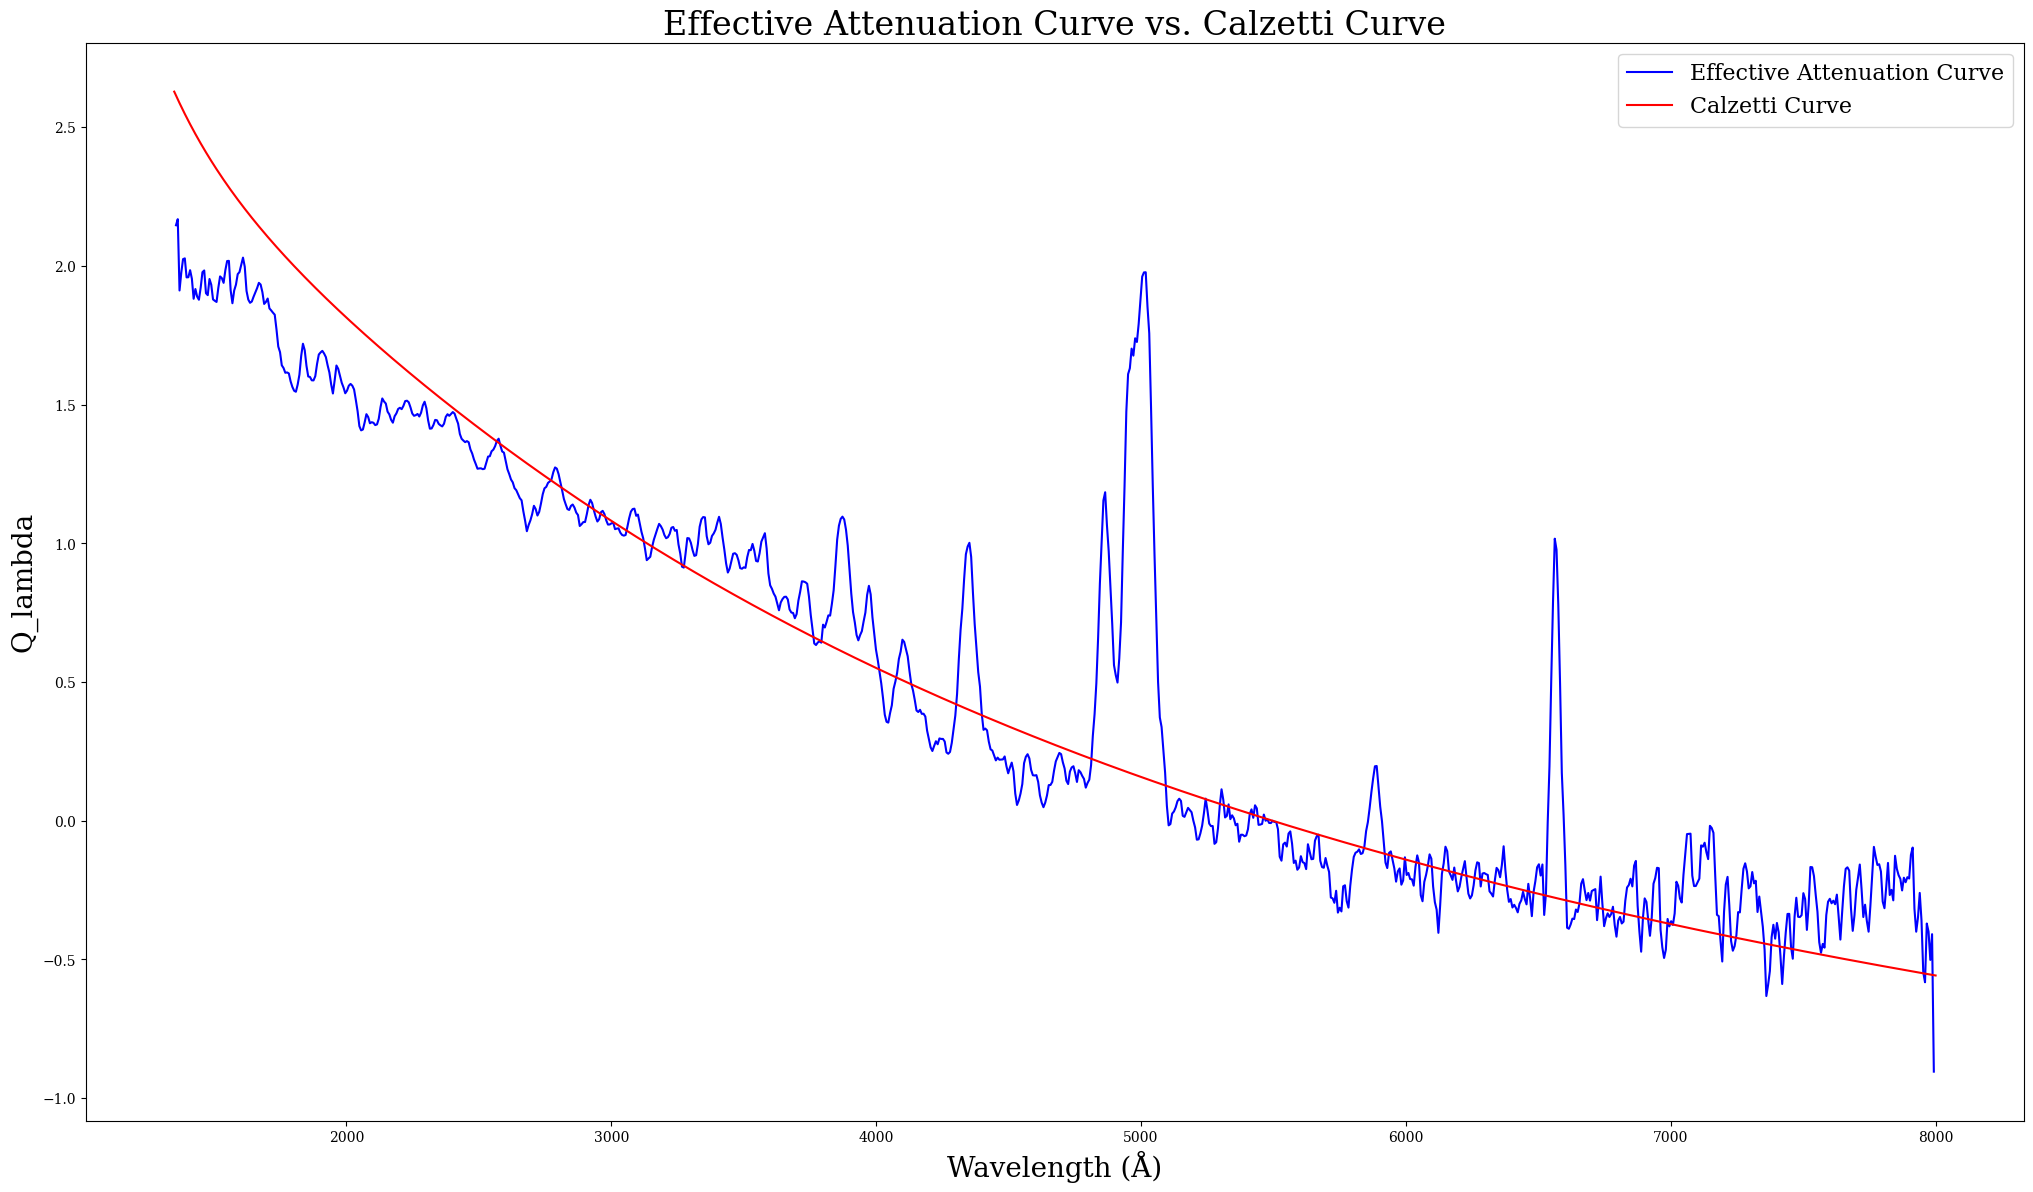

In [93]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curve vs. Calzetti Curve', fontsize=24)
plt.legend(fontsize=16)
plt.show()